In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import scipy.stats as stats
import pandas as pd
import torch
import math
pd.options.mode.chained_assignment = None
# https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
from pathlib import Path
from tqdm import tqdm
import re

from src.kernel.gaussian import Gaussian

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
def hsic(k: Gaussian,
         l: Gaussian,
         X: torch.Tensor,
         Y: torch.Tensor,
         statistic='u',
         onesampleU=True,
         compute_var=True,):
    r"""computes the HSIC of samples (Xi, Yi) ~ Pxy based on the specified (u or v)-statistics.
    X: (N, Dx) torch.Tensor
    Y: (N, Dy) torch.Tensor
    returns the scalar HSIC estimator."""
    if not X.shape[0] == Y.shape[0]:
        raise Exception(f'Expected X and Y to have the same number of samples but got {X.shape[0]} and {Y.shape[0]}.')
    Kxx = k(X, X)   # (N, N) gram matrix
    Lyy = l(Y, Y)   # (N, N) gram matrix
    return hsic_fast(Kxx,
                     Lyy,
                     statistic,
                     onesampleU,
                     compute_var)


def hsic_fast(Kxx: torch.Tensor,
              Lyy: torch.Tensor,
              statistic='u',
              onesampleU=True,
              compute_var=True,):
    r"""computes the HSIC of samples (Xi, Yi) ~ Pxy based on the specified (u or v)-statistics.
    Kxx: (N, N) gram matrix k(xi,xj)
    Lyy: (N, n) gram matrix l(yi,yj)
    returns the scalar HSIC estimator."""
    if not Kxx.shape == Lyy.shape:
        raise Exception(f'Expected Kxx and Lyy to have the same shape but got shapes {Kxx.shape} and {Lyy.shape}.')

    n = Kxx.shape[-1]
    ones = torch.ones_like(Kxx)
    eye = torch.eye(n, device=Kxx.device)
    mask = ones - eye
    Kxx_hol = mask*Kxx  # hollow matrix (diagonal zeroes)
    Lyy_hol = mask*Lyy  # NOTE: torch.fill_diagonal_ will change in-place, which affects permutation test

    if statistic=='u':
        if onesampleU:
            trKL = torch.einsum('ij,ji', Kxx_hol, Lyy_hol)
            trKL1 = torch.einsum('ij,jk->', Kxx_hol, Lyy_hol)
            trK1L1 = torch.einsum('ij,kl->', Kxx_hol, Lyy_hol)
            c1 = n*(n-3)
            c2 = n-2
            c3 = (n-1)*(n-2)
            hsic_est = (1/c1)*(trKL - (2/c2)*trKL1 + (1/c3)*trK1L1)
        else:
            ...

    elif statistic=='v':
        trKL = torch.einsum('ij,ij', Kxx, Lyy)
        trKL1 = torch.einsum('ij,jk->', Kxx, Lyy)
        trK1L1 = torch.einsum('ij,kl->', Kxx, Lyy)
        hsic_est = (1/(n**2))*trKL - (2/(n**3))*trKL1 + (1/(n**4))*trK1L1

    var_est = None
    if compute_var:
        # compute variance estimator for unbiased one-sample HSIC
        Kxx1 = Kxx_hol.sum(dim=-1)
        Lyy1 = Lyy_hol.sum(dim=-1)
        z1 = torch.sum(Kxx_hol*Lyy_hol, dim=-1)
        z2 = torch.einsum('ij,ji', Kxx_hol, Lyy_hol) - Kxx_hol @ Lyy1 - Lyy_hol @ Kxx1
        z3 = Kxx1 * Lyy1
        z4 = Lyy1.sum()*Kxx1 + Kxx1.sum()*Lyy1 - torch.sum(Kxx_hol@Lyy_hol)
        h = ((n-2)**2)*z1 + (n-2)*z2 - n*z3 + z4

        nsub1P3 = (n-1)*(n-2)*(n-3)
        r = h @ h / (4.*n*(nsub1P3**2))
        var_est = 16*(r - hsic_est**2)      # (16/n)*(r - hsic_est**2)
        var_est = torch.clamp(var_est, min=0)
    return hsic_est, var_est

cuda = torch.device('cuda:0')
k = Gaussian().to(cuda)
l = Gaussian().to(cuda)

In [9]:
# X~N(0,1) and Y=X
n_batches = 1000
n_samples = 10000
rho = 0.1
eps = torch.randn(n_batches, n_samples, 1).to(cuda)

X_alt = torch.randn(n_batches, n_samples, 1).to(cuda)
Y_alt = X_alt**2 + eps
# Y_alt = (rho)*X_alt + (1-rho)*eps

X_null = torch.randn(n_batches, n_samples, 1).to(cuda)
Y_null = X_null**2 + eps
X_null = torch.randn(n_batches, n_samples, 1).to(cuda)


In [10]:
# draw from asymptotic alternative
hsic_alt = []
for i in tqdm(range(n_batches)):
    hsic_alt.append(hsic(k, l, X_alt[i], Y_alt[i], compute_var=False)[0].item())
    # nhsic = math.sqrt(n_samples) * (hsic(k, l, X_alt[i], Y_alt[i], compute_var=False)[0] - hsic_alt) 
    # samples.append(nhsic.item())

hsic_alt = np.array(hsic_alt)
samples_alt = math.sqrt(n_samples)*(hsic_alt - hsic_alt.mean())
# print(samples)


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:45<00:00,  9.50it/s]


Text(0.012, 8.177205128688485, '$\\mathcal{H}_1: \\mathbb{P}_{XY} = \\mathbb{P}_X \\times \\mathbb{P}_Y $')

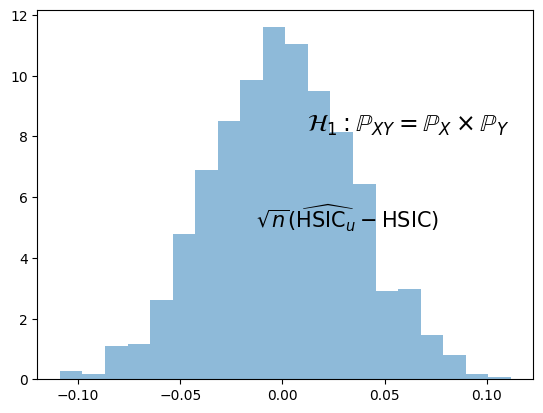

In [11]:
n_alt, x_alt, _ = plt.hist(samples_alt, bins=20, alpha=0.5, histtype='bar', density=True) # weights=np.ones(len(tau_null)) / len(tau_null)
# plt.axvline(hsic_alt.mean(), color='red')

bottom, top = plt.ylim()
plt.text(-0.013, bottom+5, s='$\\sqrt{n} ( \\widehat{\\text{HSIC}}_u - \\text{HSIC})$', size=15)
plt.text(0.012, top-4, s='$\\mathcal{H}_1: \\mathbb{P}_{XY} = \\mathbb{P}_X \\times \\mathbb{P}_Y $', size=17)
# plt.savefig(f"plots/rpe/H1_asymptotics_n={n_samples}.pdf", format="pdf", bbox_inches="tight")

In [12]:
# draw from asymptotic null
hsic_null = []
for i in tqdm(range(n_batches)):
    hsic_null.append(hsic(k, l, X_null[i], Y_null[i], compute_var=False)[0].item())

hsic_null = np.array(hsic_null)
samples_null = n_samples*hsic_null


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:45<00:00,  9.52it/s]


Text(0.34, 4.283665258020981, '$\\mathcal{H}_0: \\mathbb{P}_{XY} \\neq \\mathbb{P}_X \\times \\mathbb{P}_Y $')

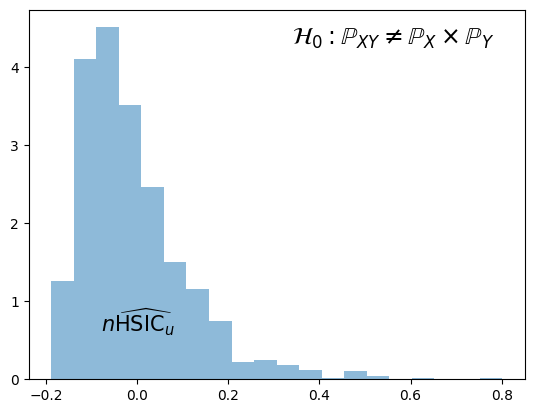

In [13]:
n_null, x_null, _ = plt.hist(samples_null, bins=20, alpha=0.5, histtype='bar', density=True) # weights=np.ones(len(tau_null)) / len(tau_null)
# plt.axvline(hsic_alt.mean(), color='red')

bottom, top = plt.ylim()
plt.text(-0.08, bottom+0.6, s='$n\\widehat{\\text{HSIC}}_u$', size=15)
plt.text(0.34, top-0.45, s='$\\mathcal{H}_0: \\mathbb{P}_{XY} \\neq \\mathbb{P}_X \\times \\mathbb{P}_Y $', size=17)
# plt.savefig(f"plots/rpe/H0_asymptotics_n={n_samples}.pdf", format="pdf", bbox_inches="tight")